<a href="https://colab.research.google.com/github/omertahakerem/statistical-analysis-II-homework/blob/main/homework_3_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

In [8]:
xls = pd.ExcelFile("veri_one_way.xlsx")
print(xls.sheet_names)


['Liste', 'veri_1-28', 'veri_29-56', 'veri_57-112', 'veri_58-168', 'aciklama']


In [9]:
df = pd.read_excel("veri_one_way.xlsx", sheet_name="veri_57-112")
df.head()

,Veri 57,Unnamed: 1,Veri 58,Unnamed: 3,Veri 59,Unnamed: 5,Veri 60,Unnamed: 7,Veri 61,Unnamed: 9,...,Veri 108,Unnamed: 103,Veri 109,Unnamed: 105,Veri 110,Unnamed: 107,Veri 111,Unnamed: 109,Veri 112,Unnamed: 111
0,Puan,Okul,Puan,Okul,Puan,Okul,Puan,Okul,Puan,Okul,...,Puan,Okul,Puan,Okul,Puan,Okul,Puan,Okul,Puan,Okul
1,31.8187,A,31.9831,A,93.9804,A,26.6496,A,17.056,A,...,65,A,56,A,55,A,57,A,51,A
2,81.8762,A,94.89,A,89.3302,A,93.4521,A,75.5691,A,...,60,A,67,A,47,A,52,A,56,A
3,24.735,A,75.1515,A,46.0663,A,77.511,A,84.999,A,...,70,A,44,A,54,A,48,A,43,A
4,65.2446,A,89.0948,A,93.7446,A,94.6866,A,96.7726,A,...,55,A,62,A,45,A,52,A,61,A


In [10]:
veri69 = df[["Veri 69", "Unnamed: 25"]].copy()
veri69.columns = ["Puan", "Okul"]

veri69.head()

,Puan,Okul
0,Puan,Okul
1,79.0754,A
2,21.5639,A
3,43.3373,A
4,68.2409,A


Türkçe

Tek yönlü varyans analizinin uygulanabilmesi için öncelikle normallik varsayımının sağlanması gerekmektedir. Bu nedenle her bir grup için Shapiro-Wilk normallik testi uygulanacaktır. Eğer p-değeri 0.05’ten büyük çıkarsa ilgili grubun normal dağıldığı kabul edilecektir.

English

In order to apply One-Way ANOVA, the normality assumption must be satisfied. Therefore, the Shapiro-Wilk normality test will be applied for each group. If the p-value is greater than 0.05, the group is considered to be normally distributed.

In [11]:
from scipy.stats import shapiro

print("A grubu:", shapiro(veri69[veri69["Okul"]=="A"]["Puan"]))
print("B grubu:", shapiro(veri69[veri69["Okul"]=="B"]["Puan"]))
print("C grubu:", shapiro(veri69[veri69["Okul"]=="C"]["Puan"]))

A grubu: ShapiroResult(statistic=np.float64(0.8645643441462141), pvalue=np.float64(0.1662543035181397))
B grubu: ShapiroResult(statistic=np.float64(0.8717378455208709), pvalue=np.float64(0.15673322465704925))
C grubu: ShapiroResult(statistic=np.float64(0.8860211484350151), pvalue=np.float64(0.15288417221797346))


Türkçe

Shapiro-Wilk normallik testi sonuçlarına göre A, B ve C grupları için elde edilen p-değerleri sırasıyla 0.166, 0.157 ve 0.153 olarak bulunmuştur. Bu değerlerin tamamı 0.05 anlamlılık düzeyinden büyük olduğu için her bir grubun normal dağıldığı kabul edilir. Bu nedenle parametrik testlerin uygulanması uygundur.

English

According to the Shapiro-Wilk normality test results, the p-values for groups A, B, and C were found to be 0.166, 0.157, and 0.153, respectively. Since all of these values are greater than the significance level of 0.05, each group is considered to be normally distributed. Therefore, it is appropriate to use parametric tests.

Türkçe

Tek yönlü varyans analizinin uygulanabilmesi için bir diğer önemli varsayım varyansların homojen olmasıdır. Bu varsayımı test etmek amacıyla Levene testi uygulanacaktır. Eğer p-değeri 0.05’ten büyük çıkarsa grupların varyanslarının eşit olduğu kabul edilir.

English

Another important assumption for One-Way ANOVA is the homogeneity of variances. Levene’s test will be applied to test this assumption. If the p-value is greater than 0.05, the variances of the groups are considered equal.

In [12]:
from scipy.stats import levene

A = veri69[veri69["Okul"]=="A"]["Puan"]
B = veri69[veri69["Okul"]=="B"]["Puan"]
C = veri69[veri69["Okul"]=="C"]["Puan"]

stat, p = levene(A, B, C)
print("Levene p-değeri:", p)


Levene p-değeri: 0.6081280133572353


Türkçe

Levene testi sonucunda p-değeri 0.608 olarak bulunmuştur. Bu değer 0.05 anlamlılık düzeyinden büyük olduğu için grupların varyanslarının eşit olduğu kabul edilir. Dolayısıyla homojenlik varsayımı sağlanmıştır.

English

According to the Levene test, the p-value was found to be 0.608. Since this value is greater than the significance level of 0.05, the variances of the groups are considered equal. Therefore, the homogeneity assumption is satisfied.

Türkçe

Normallik ve varyans homojenliği varsayımları sağlandığı için gruplar arasında ortalama farklarını incelemek amacıyla tek yönlü varyans analizi (One-Way ANOVA) uygulanacaktır.

English

Since the assumptions of normality and homogeneity of variances are satisfied, One-Way ANOVA will be applied to examine the differences between group means.

In [13]:
from scipy.stats import f_oneway

stat, p = f_oneway(A, B, C)

print("F istatistiği:", stat)
print("p-değeri:", p)

F istatistiği: 0.5037233103640436
p-değeri: 0.6110782622810227


Türkçe

Tek yönlü varyans analizi sonucunda p-değeri 0.61 olarak bulunmuştur. Bu değer 0.05 anlamlılık düzeyinden büyük olduğu için sıfır hipotezi reddedilemez. Buna göre A, B ve C okullarına ait öğrencilerin mesleki sınav puan ortalamaları arasında istatistiksel olarak anlamlı bir fark bulunmamaktadır.

English

According to the One-Way ANOVA results, the p-value was found to be 0.61. Since this value is greater than the significance level of 0.05, the null hypothesis cannot be rejected. Therefore, there is no statistically significant difference between the mean exam scores of students from schools A, B, and C.

Türkçe

ANOVA sonucunda anlamlı bir fark bulunmadığı için gruplar arasında hangi grubun farklılık yarattığını belirlemek amacıyla ek bir post-hoc test yapılmasına gerek yoktur.

English

Since no significant difference was found in the ANOVA results, there is no need to perform a post-hoc test to determine which group differs from the others.

Türkçe

Analiz sonuçlarını görsel olarak desteklemek amacıyla okul gruplarına göre puan dağılımlarını gösteren bir kutu grafiği oluşturulacaktır.

English

In order to visually support the analysis results, a boxplot showing the score distributions by school groups will be created.

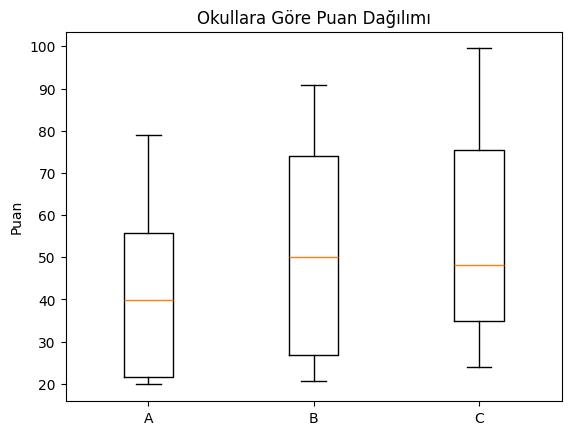

In [15]:
import matplotlib.pyplot as plt

plt.boxplot([A, B, C])
plt.xticks([1, 2, 3], ["A", "B", "C"])
plt.title("Okullara Göre Puan Dağılımı")
plt.ylabel("Puan")
plt.show()